# 📊 Seaborn
Seaborn es una biblioteca de visualización de datos en Python basada en Matplotlib. Proporciona una interfaz de alto nivel para crear gráficos estadísticos atractivos y fáciles de interpretar. Seaborn está diseñado para trabajar bien con estructuras de datos como DataFrames de pandas, lo que facilita la creación de gráficos complejos con pocas líneas de código.

## Instalación
Para instalar Seaborn, puedes usar pip. Abre tu terminal o línea de comandos y ejecuta el siguiente comando:
```bash
pip install seaborn
```
## Importación
Para comenzar a usar Seaborn en tu proyecto de Python, primero debes importarlo. También es común importar Matplotlib para personalizar los gráficos si es necesario:
```python
import seaborn as sns
import matplotlib.pyplot as plt
```
## Ejemplo básico
Cómo crear un gráfico de dispersión utilizando Seaborn:

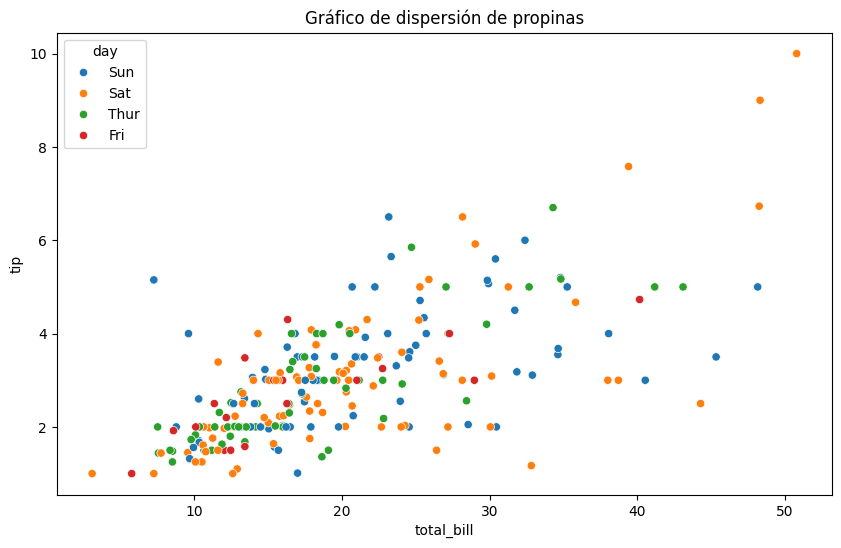

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import requests
import pandas as pd
from io import StringIO
import urllib3

# repositorio de datos publicos para los cursos
url="https://patricioaraneda.cl/public"

# Suppress insecure request warnings when using verify=False below (only for local/example use).
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

# Cargar un conjunto de datos de ejemplo desde el repositorio de seaborn usando requests
# Usamos verify=False para evitar el error de validación SSL en entornos locales.
urldata = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/tips.csv"
resp = requests.get(urldata, verify=False)
resp.raise_for_status()
tips = pd.read_csv(StringIO(resp.text))

# Crear un gráfico de dispersión
plt.figure(figsize=(10, 6))
sns.scatterplot(data=tips, x="total_bill", y="tip", hue="day")
plt.title("Gráfico de dispersión de propinas")
plt.show()

## Documentación oficial
Para obtener más información sobre Seaborn y explorar todas sus funcionalidades, puedes visitar la [documentación oficial de Seaborn](https://seaborn.pydata.org/).

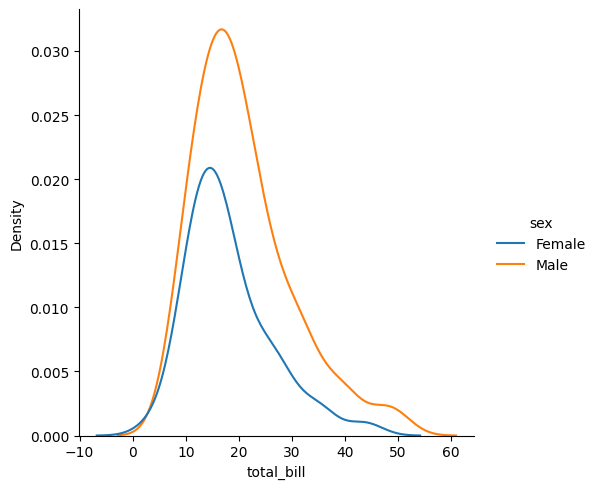

In [ ]:
sns.displot( data=tips, x='total_bill', kind='kde', hue='sex' )

# Análisis exploratorio (EDA) — Titanic

Objetivo: 
explorar la estructura, distribuciones, relaciones y valores perdidos del archivo '../data/titanic5_full.csv' usando únicamente gráficos de seaborn. A continuación se presentan los pasos recomendados y fragmentos de código listos para ejecutar en celdas de código (no repetir imports ya presentes).

Carga y resumen inicial


In [3]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv(f'{url}/titanic5_price_clean.csv')
df.head()
df.info()
df.describe(include='all')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2208 entries, 0 to 2207
Data columns (total 18 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Sex          2208 non-null   int64  
 1   Age          2154 non-null   float64
 2   Class/Dept   2208 non-null   object 
 3   Class        2208 non-null   object 
 4   Ticket       1317 non-null   object 
 5   Joined       2208 non-null   object 
 6   Occupation   1587 non-null   object 
 7   Boat [Body]  2208 non-null   object 
 8   Price        2208 non-null   float64
 9   Job          958 non-null    object 
 10  Survived     2208 non-null   int64  
 11  Title        2208 non-null   object 
 12  DoB          1231 non-null   object 
 13  Year_Birth   621 non-null    object 
 14  Date_Death   2087 non-null   object 
 15  DoB_Clean    1853 non-null   object 
 16  sibsp        1309 non-null   float64
 17  parch        1309 non-null   float64
dtypes: float64(4), int64(2), object(12)
memory usage

,Sex,Age,Class/Dept,Class,Ticket,Joined,Occupation,Boat [Body],Price,Job,Survived,Title,DoB,Year_Birth,Date_Death,DoB_Clean,sibsp,parch
count,2208.000000,2154.000000,2208,2208,1317,2208,1587,2208,2208.000000,958,2208.000000,2208,1231,621,2087,1853,1309.000000,1309.000000
unique,NaN,NaN,8,8,927,4,371,260,NaN,6,NaN,23,1181,81,588,1258,NaN,NaN
top,NaN,NaN,3rd Class Passenger,3,2343,Southampton,Fireman,,NaN,,NaN,Mr,1887-12-06,1884,1912-04-15,1884-06-30,NaN,NaN
freq,NaN,NaN,709,709,11,1614,161,1340,NaN,885,NaN,1587,3,30,1496,30,NaN,NaN
mean,0.778533,30.158770,NaN,NaN,NaN,NaN,NaN,NaN,19.736590,NaN,0.322464,NaN,NaN,NaN,NaN,NaN,0.498854,0.385027
std,0.415328,11.958248,NaN,NaN,NaN,NaN,NaN,NaN,43.255382,NaN,0.467525,NaN,NaN,NaN,NaN,NaN,1.041658,0.865560
min,0.000000,0.170000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
25%,1.000000,22.000000,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
50%,1.000000,29.000000,NaN,NaN,NaN,NaN,NaN,NaN,7.750000,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
75%,1.000000,37.000000,NaN,NaN,NaN,NaN,NaN,NaN,20.250000,NaN,1.000000,NaN,NaN,NaN,NaN,NaN,1.000000,0.000000


In [ ]:
# Configuración estética (opcional)
sns.set_theme(style='whitegrid', palette='deep')

### Gráficos recomendados

**1) Mapa de valores faltantes**

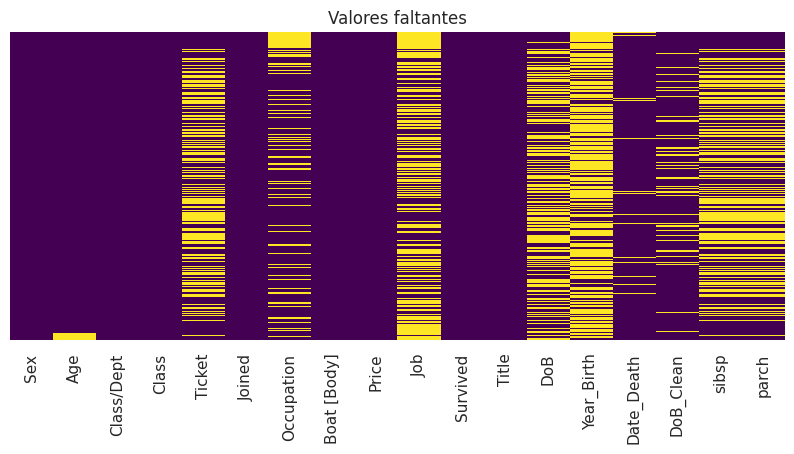

In [ ]:
plt.figure(figsize=(10,4))
sns.heatmap(df.isnull(), cbar=False, yticklabels=False, cmap='viridis')
plt.title('Valores faltantes')
plt.show()

Distribuciones univariadas (numéricas)
- Age, Fare, SibSp, Parch

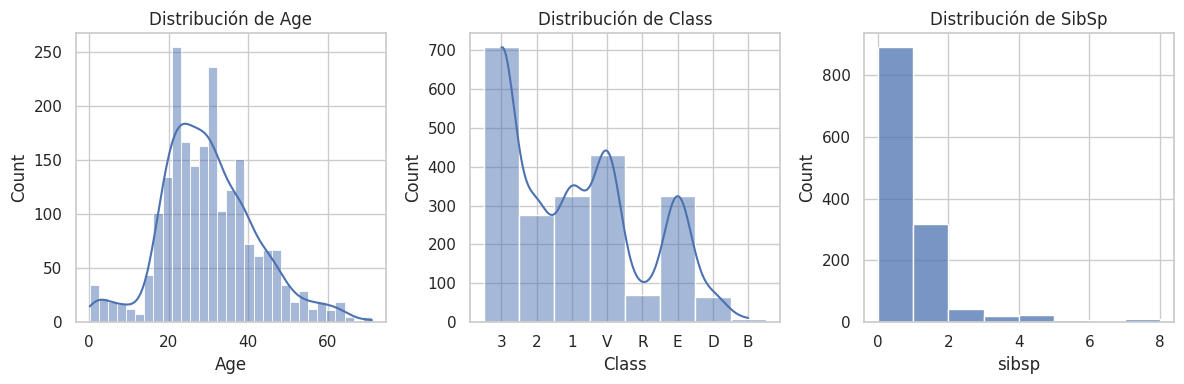

In [ ]:

plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.histplot(df['Age'].dropna(), kde=True)
plt.title('Distribución de Age')

plt.subplot(1,3,2)
sns.histplot(df['Class'].dropna(), kde=True)
plt.title('Distribución de Class')

plt.subplot(1,3,3)
sns.histplot(df['sibsp'].dropna(), kde=False, bins=8)
plt.title('Distribución de SibSp')
plt.tight_layout()
plt.show()


3) Boxplots 
- violines para detectar outliers y comparar por grupo

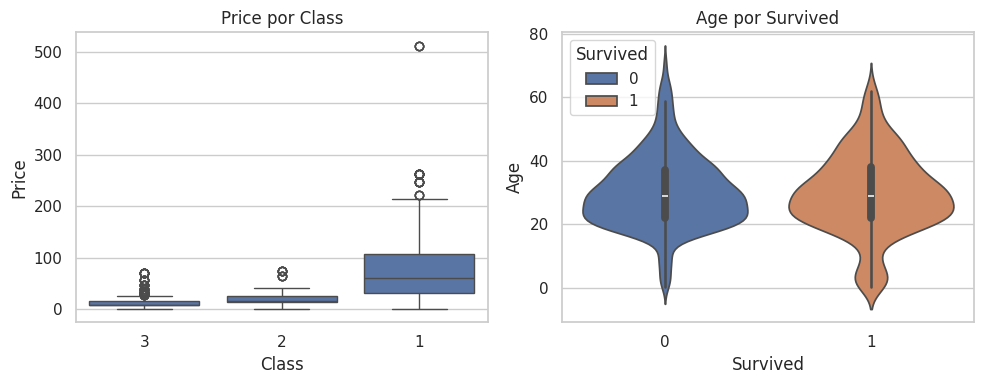

In [ ]:

plt.figure(figsize=(10,4))
plt.subplot(1,2,1)
sel_df = df[df['Class'].astype(str).isin(['1','2','3'])]
sns.boxplot(x='Class', y='Price', data=sel_df)
plt.title('Price por Class')

plt.subplot(1,2,2)
sns.violinplot(x='Survived', y='Age', data=df, hue='Survived', split=False)
plt.title('Age por Survived')
plt.tight_layout()
plt.show()



4) Conteos de variables categóricas
- survived, sex, pclass, embarked


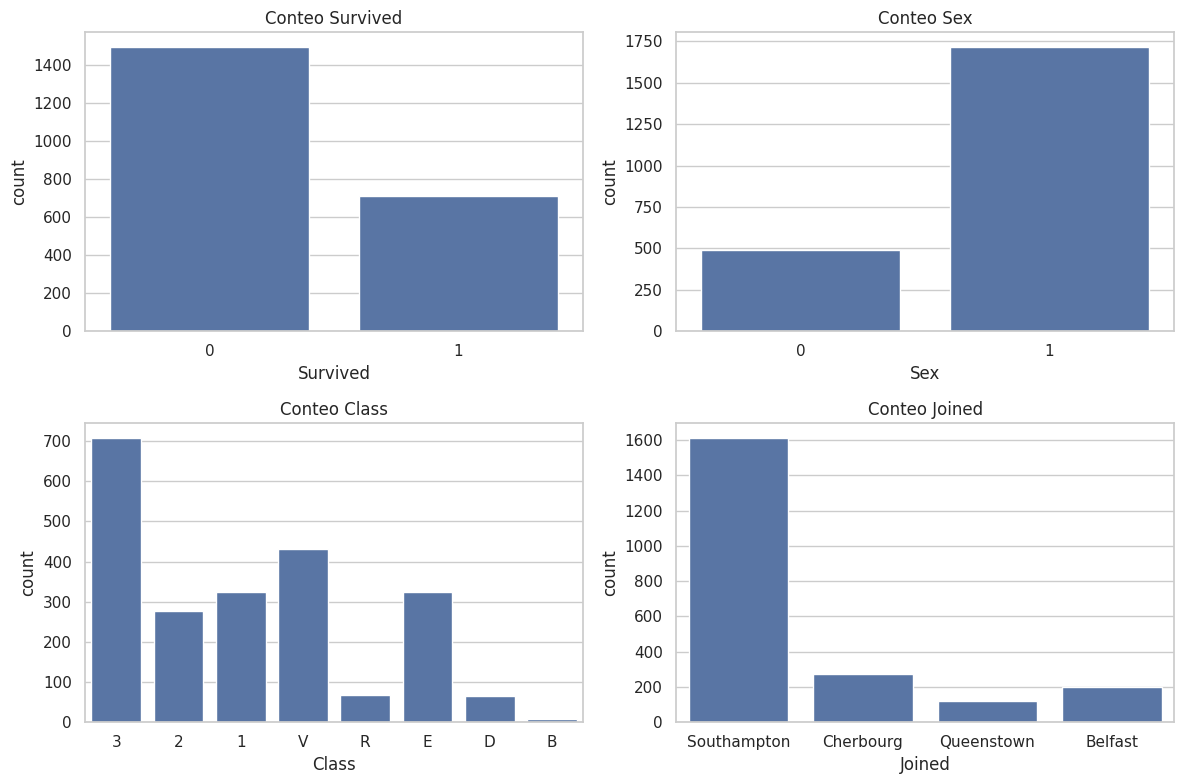

In [ ]:

plt.figure(figsize=(12,8))
plt.subplot(2,2,1)
sns.countplot(x='Survived', data=df)
plt.title('Conteo Survived')

plt.subplot(2,2,2)
sns.countplot(x='Sex', data=df)
plt.title('Conteo Sex')

plt.subplot(2,2,3)
sns.countplot(x='Class', data=df)
plt.title('Conteo Class')

plt.subplot(2,2,4)
sns.countplot(x='Joined', data=df)
plt.title('Conteo Joined')
plt.tight_layout()
plt.show()


5) Tasa de supervivencia por categoría (barplot con mean)

/tmp/ipykernel_36570/713937189.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Class', y='Survived', data=df, ci=None)
/tmp/ipykernel_36570/713937189.py:7: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Sex', y='Survived', data=df, ci=None)
/tmp/ipykernel_36570/713937189.py:11: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(x='Joined', y='Survived', data=df, ci=None)


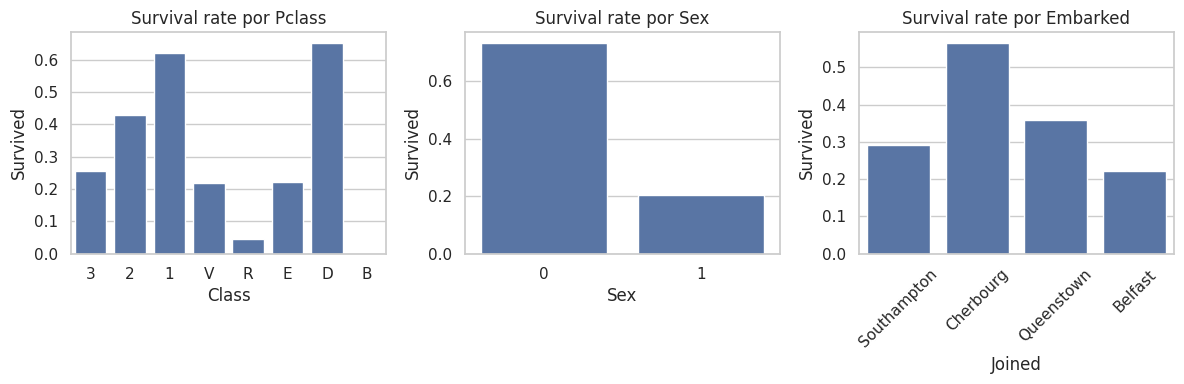

In [ ]:
plt.figure(figsize=(12,4))
plt.subplot(1,3,1)
sns.barplot(x='Class', y='Survived', data=df, errorbar=None)
plt.title('Survival rate por Pclass')

plt.subplot(1,3,2)
sns.barplot(x='Sex', y='Survived', data=df, errorbar=None)
plt.title('Survival rate por Sex')

plt.subplot(1,3,3)
sns.barplot(x='Joined', y='Survived', data=df, errorbar=None)
plt.title('Survival rate por Embarked')
# rota 45 grados xlabels
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


6) Interacciones categóricas (FacetGrid / catplot)
- Survival por Class y Sex

/tmp/ipykernel_36570/1010995085.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.catplot(x='Class', y='Survived', hue='Sex', kind='point', data=df, ci=None, height=4, aspect=1.5)


<Figure size 1000x600 with 0 Axes>

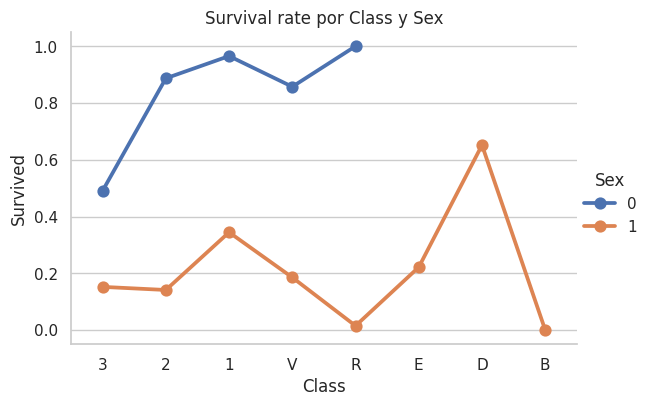

In [ ]:
plt.figure(figsize=(10,6))
sns.catplot(x='Class', y='Survived', hue='Sex', kind='point', data=df, ci=None, height=4, aspect=1.5)
plt.title('Survival rate por Class y Sex')
plt.show()


7) Relaciones numéricas bivariadas
- Age vs Fare coloreado por Survived


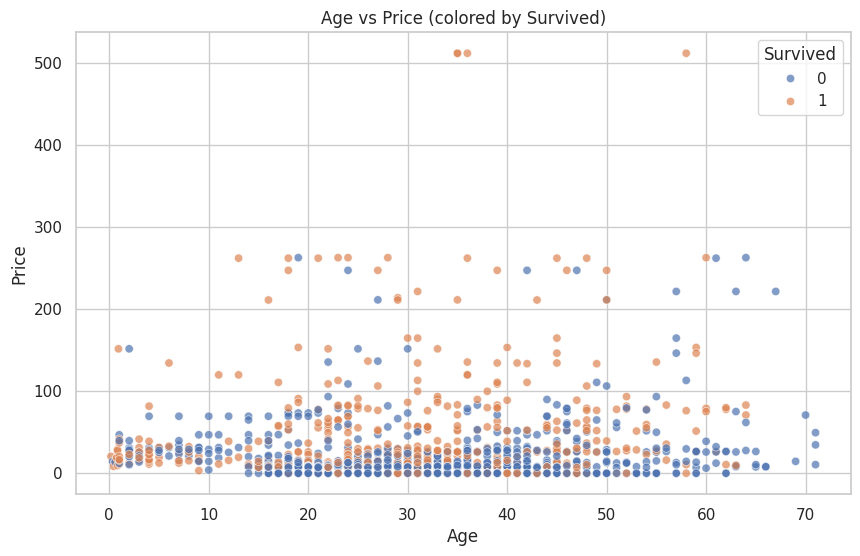

In [ ]:

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='Age', y='Price', hue='Survived', alpha=0.7)
plt.title('Age vs Price (colored by Survived)')
plt.show()



- Si hay muchos puntos, usar kdeplot o hexbin-style con jointplot


<Figure size 1000x600 with 0 Axes>

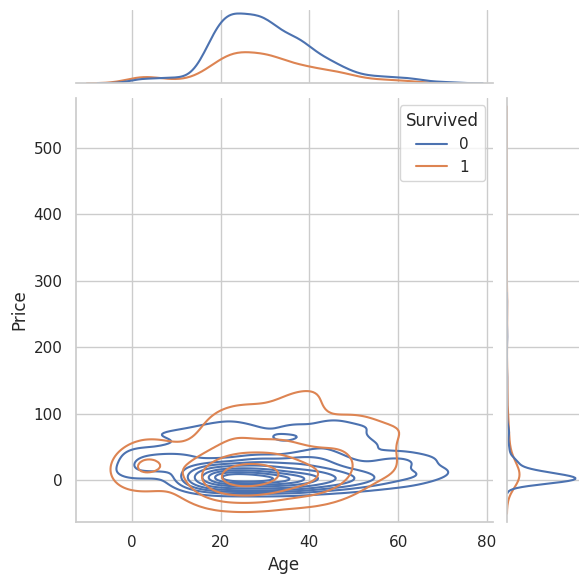

In [ ]:
# define tamaño de figura a 10,6
plt.figure(figsize=(10,6))

sns.jointplot(data=df, x='Age', y='Price', kind='kde', hue='Survived')
plt.show()




8) Matriz de correlación (numéricas) y heatmap


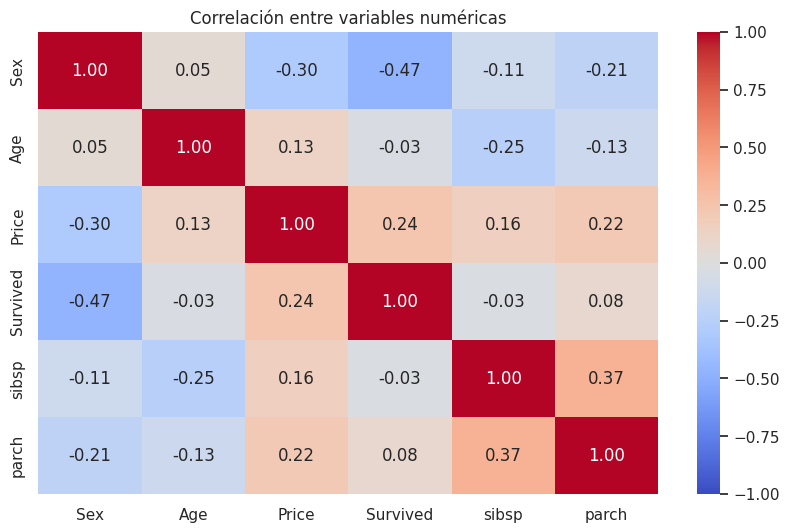

In [ ]:
num = df.select_dtypes(include=['int64','float64'])
corr = num.corr()
plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlación entre variables numéricas')
plt.show()



9) Pairplot para ver relaciones múltiples (filtrar columnas si hay muchas)


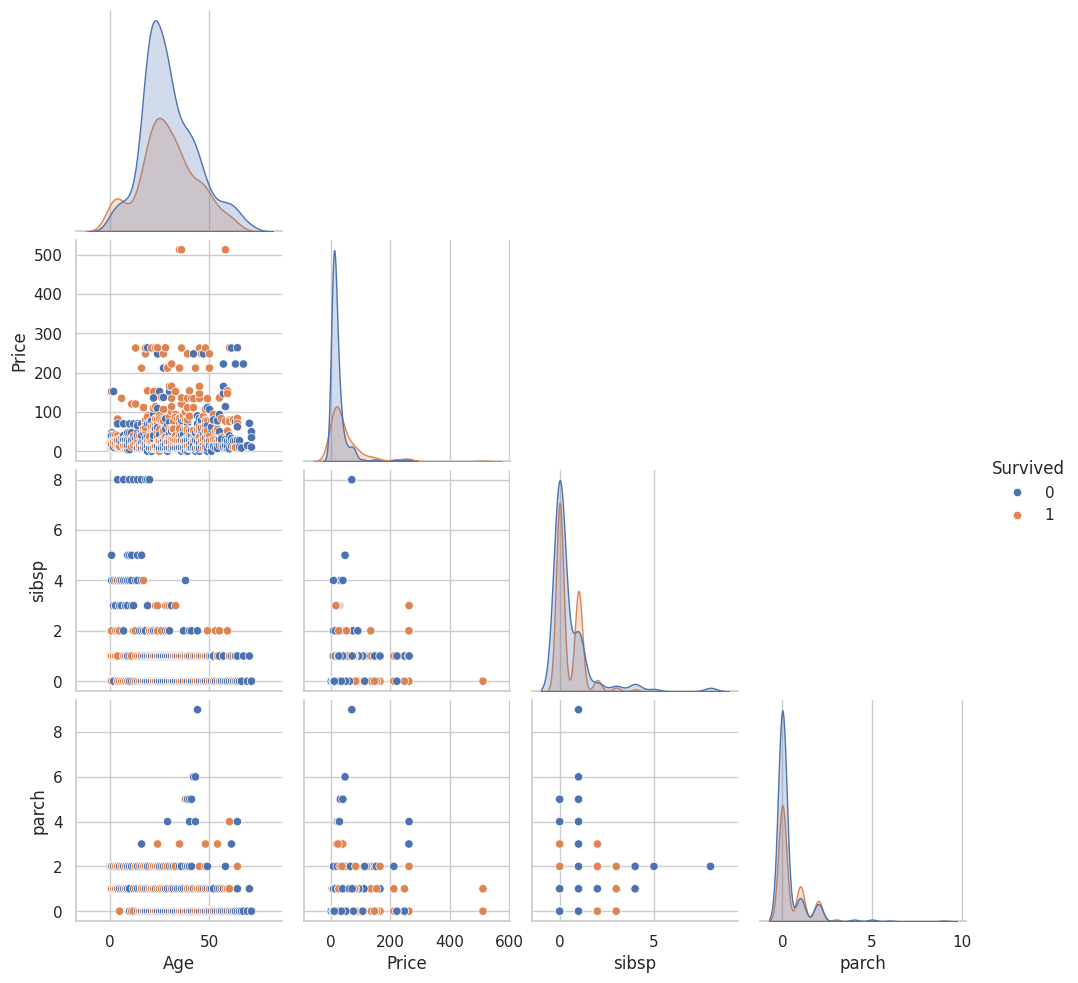

In [ ]:

cols = ['Survived','Age','Price','sibsp','parch']
sns.pairplot(df[cols].dropna(), hue='Survived', diag_kind='kde', corner=True)
plt.show()




10) Análisis de títulos / familias si existen (feature engineering)
- Si hay columna name: extraer título y visualizar survival por título (ejemplo)

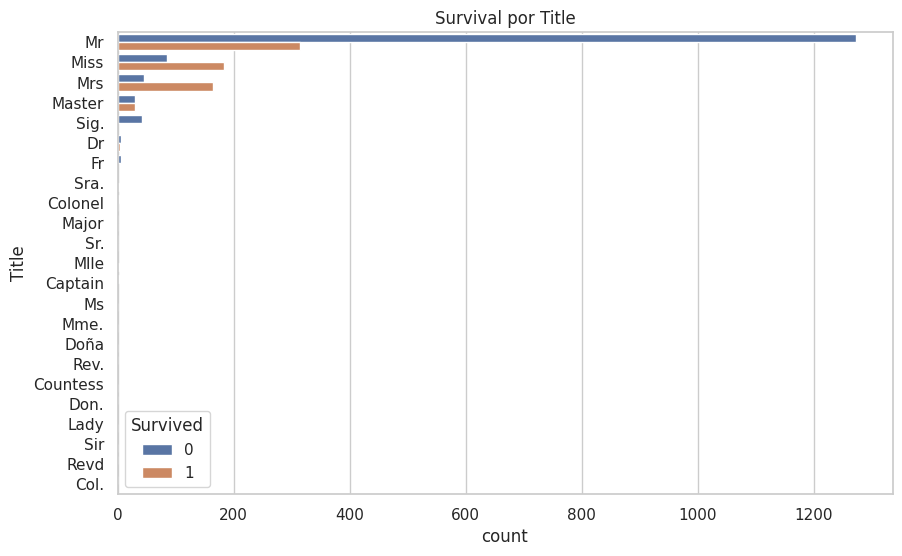

In [ ]:
# ejemplo de ingeniería si aplica
#df['title'] = df['name'].str.extract(',\s*([^\.]+)\.')
plt.figure(figsize=(10,6))
sns.countplot(y='Title', hue='Survived', data=df, order=df['Title'].value_counts().index)
plt.title('Survival por Title')
plt.show()



11) Análisis de tamaño familiar (SibSp + Parch)


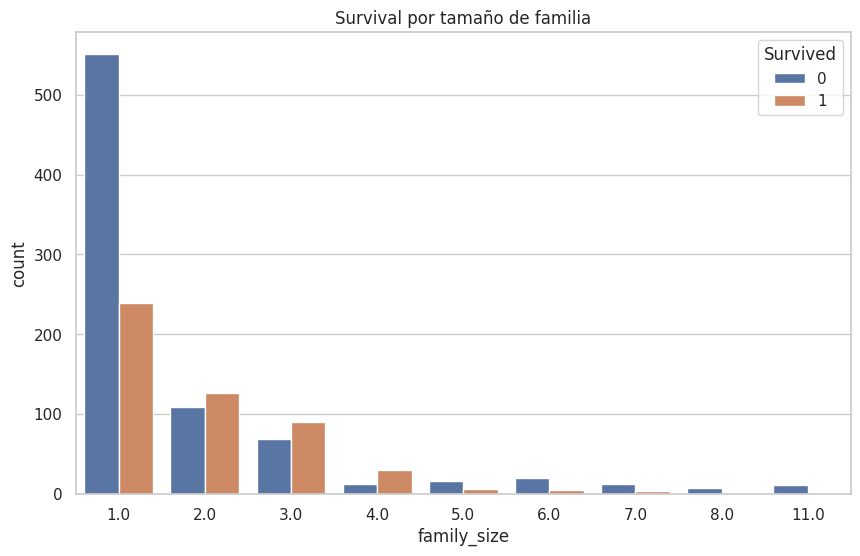

In [ ]:

df['family_size'] = df.get('sibsp', df.get('sibsp', 0)) + df.get('parch', df.get('parch', 0)) + 1
plt.figure(figsize=(10,6))
sns.countplot(x='family_size', hue='Survived', data=df)
plt.title('Survival por tamaño de familia')
plt.show()
